In [5]:
import csv
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path("__file__").resolve().parent
if not (ROOT / "pickcube_baseline.csv").exists():
    ROOT = ROOT / "make_plots"

ROBOT_STYLES = {
    "weak": {
        "scratch":  {"color": "#820000", "linestyle": "-"},
        "finetune": {"color": "#E50808", "linestyle": "--"},
    },
    "damped": {
        "scratch":  {"color": "#00548f", "linestyle": "-"},
        "finetune": {"color": "#6FC3FF", "linestyle": "--"},
    },
    "weakdamped": {
        "scratch":  {"color": "#006F54", "linestyle": "-"},
        "finetune": {"color": "#1AECBA", "linestyle": "--"},
    },
    "panda": {
        "baseline": {"color": "#544948", "linestyle": "-"},
    },
}

REWARD_THRESHOLDS = (0.5, 0.8)


@dataclass
class Series:
    label: str
    steps: list
    values: list
    robot: str
    variant: str


def iter_mean_columns(header):
    for idx, name in enumerate(header):
        if idx == 0:
            continue
        if name.endswith("__MIN") or name.endswith("__MAX"):
            continue
        yield idx, name


def classify_series(raw):
    name = raw.replace(" - eval/reward", "")
    if "weakdampedpanda" in name:
        robot = "weakdamped"
    elif "dampedpanda" in name:
        robot = "damped"
    elif "weakpanda" in name:
        robot = "weak"
    else:
        robot = "panda"
    if "finetune" in name:
        variant = "finetune"
    elif "fromscratch" in name:
        variant = "scratch"
    else:
        variant = "baseline"
    return robot, variant


def shorten_label(raw):
    robot, variant = classify_series(raw)
    return f"{robot} | {variant}"


def load_series(path):
    with open(path, newline="") as f:
        rows = list(csv.reader(f))
    header, data_rows = rows[0], rows[1:]
    series_list = []
    for idx, raw_name in iter_mean_columns(header):
        steps, values = [], []
        for row in data_rows:
            if row[idx] == "":
                continue
            steps.append(int(float(row[0])))
            values.append(float(row[idx]))
        robot, variant = classify_series(raw_name)
        series_list.append(Series(shorten_label(raw_name), steps, values, robot, variant))
    return series_list


def first_step_at_or_above(steps, values, threshold):
    for step, value in zip(steps, values):
        if value >= threshold:
            return step
    return None


def auc_normalized(steps, values):
    if len(steps) < 2:
        return None
    auc = sum(
        (values[i] + values[i-1]) / 2.0 * (steps[i] - steps[i-1])
        for i in range(1, len(steps))
    )
    span = steps[-1] - steps[0]
    return auc / span if span > 0 else None


pickcube  = load_series(ROOT / "pickcube_baseline.csv")
stackcube = load_series(ROOT / "stackcube_baseline.csv")
print(f"Loaded {len(pickcube)} PickCube series, {len(stackcube)} StackCube series")

Loaded 7 PickCube series, 7 StackCube series


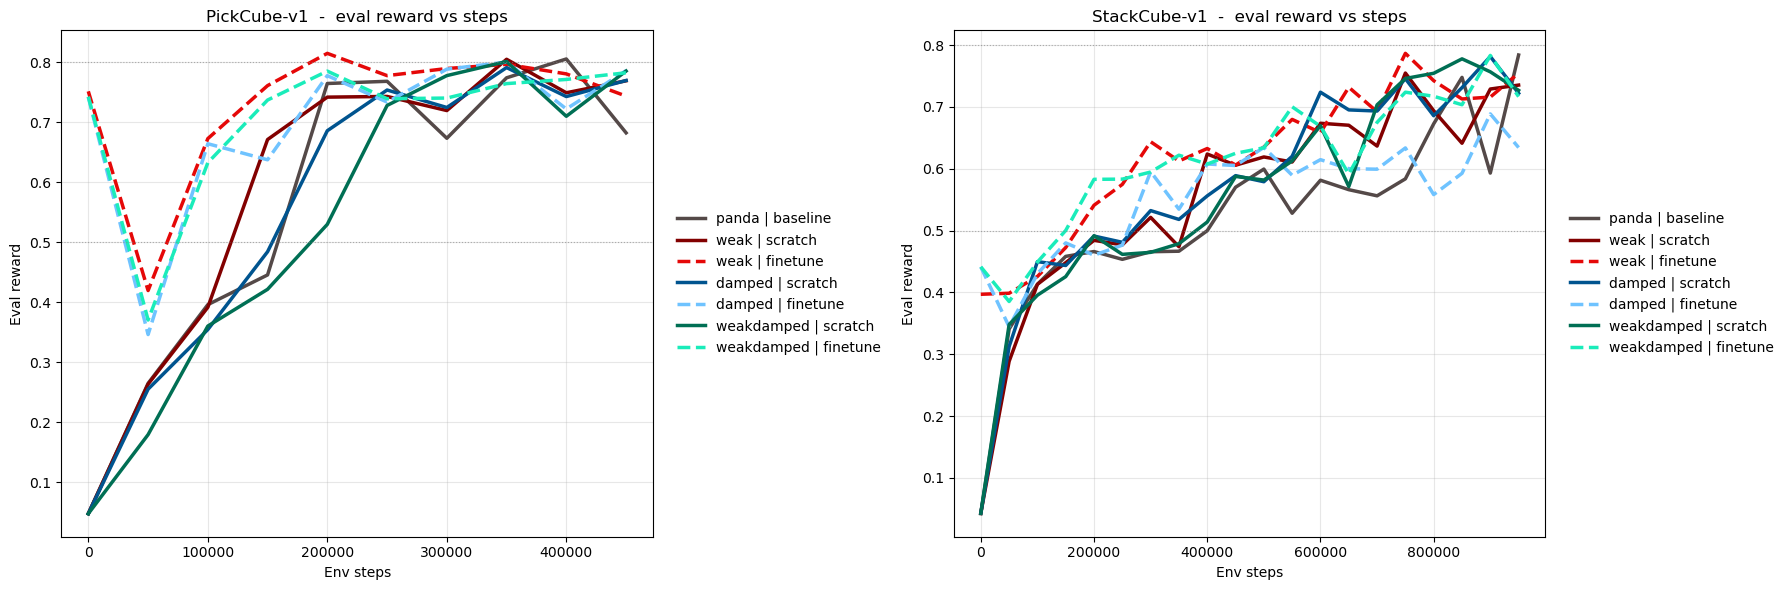

In [6]:
# Original side-by-side: one plot per task
def plot_task(ax, series_list, title):
    order = {"panda": 0, "weak": 1, "damped": 2, "weakdamped": 3}
    variant_order = {"baseline": 0, "scratch": 1, "finetune": 2}
    series_list = sorted(
        series_list,
        key=lambda s: (order.get(s.robot, 99), variant_order.get(s.variant, 99), s.label)
    )
    for s in series_list:
        style = ROBOT_STYLES.get(s.robot, {}).get(s.variant, {})
        ax.plot(
            s.steps, s.values,
            label=s.label,
            color=style.get("color"),
            linestyle=style.get("linestyle", "-"),
            linewidth=2.5,
        )
    for t in REWARD_THRESHOLDS:
        ax.axhline(t, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_title(title)
    ax.set_xlabel("Env steps")
    ax.set_ylabel("Eval reward")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
plot_task(ax1, pickcube,  "PickCube-v1  -  eval reward vs steps")
plot_task(ax2, stackcube, "StackCube-v1  -  eval reward vs steps")
fig.tight_layout()
plt.show()

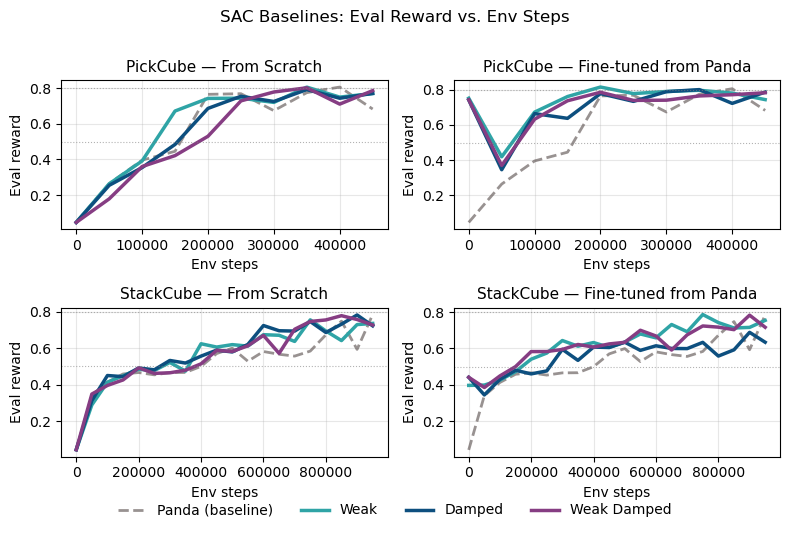

In [43]:
# 2x2 grid: rows = tasks (PickCube / StackCube), cols = scratch | finetune
# panda baseline plotted on both columns for reference; shared legend at bottom
import matplotlib.lines as mlines

ROBOT_COLOR = {
    "panda":      "#544948",
    "weak":       "#2FA4A6",
    "damped":     "#0d4f7f",
    "weakdamped": "#863D83",
}

ROBOT_DISPLAY = {
    "panda":      "Panda (baseline)",
    "weak":       "Weak",
    "damped":     "Damped",
    "weakdamped": "Weak Damped",
}

def plot_split(ax, series_list, mode, title):
    order = {"panda": 0, "weak": 1, "damped": 2, "weakdamped": 3}
    keep = [s for s in series_list if s.variant == mode or s.variant == "baseline"]
    keep = sorted(keep, key=lambda s: order.get(s.robot, 99))
    for s in keep:
        is_baseline = s.variant == "baseline"
        ax.plot(
            s.steps, s.values,
            color=ROBOT_COLOR.get(s.robot, "black"),
            linestyle="--" if is_baseline else "-",
            linewidth=2 if is_baseline else 2.5,
            alpha=0.6 if is_baseline else 1.0,
        )
    for t in REWARD_THRESHOLDS:
        ax.axhline(t, color="gray", linewidth=0.8, linestyle=":", alpha=0.6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("Env steps")
    ax.set_ylabel("Eval reward")
    ax.grid(True, alpha=0.3)


fig, axes = plt.subplots(2, 2, figsize=(8, 5))

plot_split(axes[0, 0], pickcube,  "scratch",  "PickCube — From Scratch")
plot_split(axes[0, 1], pickcube,  "finetune", "PickCube — Fine-tuned from Panda")
plot_split(axes[1, 0], stackcube, "scratch",  "StackCube — From Scratch")
plot_split(axes[1, 1], stackcube, "finetune", "StackCube — Fine-tuned from Panda")

# Shared legend: dashed entry for panda baseline, solid for the rest
handles = [
    mlines.Line2D([], [], color=ROBOT_COLOR[robot],
                  linestyle="--" if robot == "panda" else "-",
                  linewidth=2 if robot == "panda" else 2.5,
                  alpha=0.6 if robot == "panda" else 1.0,
                  label=label)
    for robot, label in ROBOT_DISPLAY.items()
]
fig.legend(handles=handles, loc="lower center", ncol=len(ROBOT_DISPLAY),
           frameon=False, fontsize=10, bbox_to_anchor=(0.5, -0.03))
fig.suptitle("SAC Baselines: Eval Reward vs. Env Steps", fontsize=12, y=1.01)
fig.tight_layout()
plt.savefig(ROOT / "baseline_rewards.png", bbox_inches="tight", dpi=300)
plt.show()

In [ ]:
# Sample efficiency summary table
import pandas as pd

rows = []
for task, series_list in [("PickCube", pickcube), ("StackCube", stackcube)]:
    for s in series_list:
        rows.append({
            "task":         task,
            "label":        s.label,
            "steps to 0.5": first_step_at_or_above(s.steps, s.values, 0.5),
            "steps to 0.8": first_step_at_or_above(s.steps, s.values, 0.8),
            "AUC_norm":     round(auc_normalized(s.steps, s.values) or 0, 4),
            "final_reward": round(s.values[-1], 4) if s.values else None,
        })

pd.DataFrame(rows)